# Chapter 100 — Angle Measurement

> **Prerequisites:** ch099 (Circles), ch093 (Cartesian Coordinates)
>
> **Outcomes:** Convert between degrees and radians; Understand why radians are natural; Measure angles between vectors; Use atan2 correctly


## Radians vs Degrees

**Degrees:** historical, intuitive, 360° in a full turn.
**Radians:** mathematical, natural — defined so that arc length = radius × angle.

Conversion: θ_rad = θ_deg × π/180
At r=1 (unit circle): arc length = θ in radians. This is why radians appear naturally in calculus.

Key reference angles:
| Degrees | Radians | sin | cos |
|---------|---------|-----|-----|
| 0 | 0 | 0 | 1 |
| 30 | π/6 | 1/2 | √3/2 |
| 45 | π/4 | √2/2 | √2/2 |
| 60 | π/3 | √3/2 | 1/2 |
| 90 | π/2 | 1 | 0 |
| 180 | π | 0 | -1 |
| 360 | 2π | 0 | 1 |

**Why radians?** The derivative of sin(x) is cos(x) only in radians. In degrees it would be (π/180)cos(x). Radians make calculus clean.

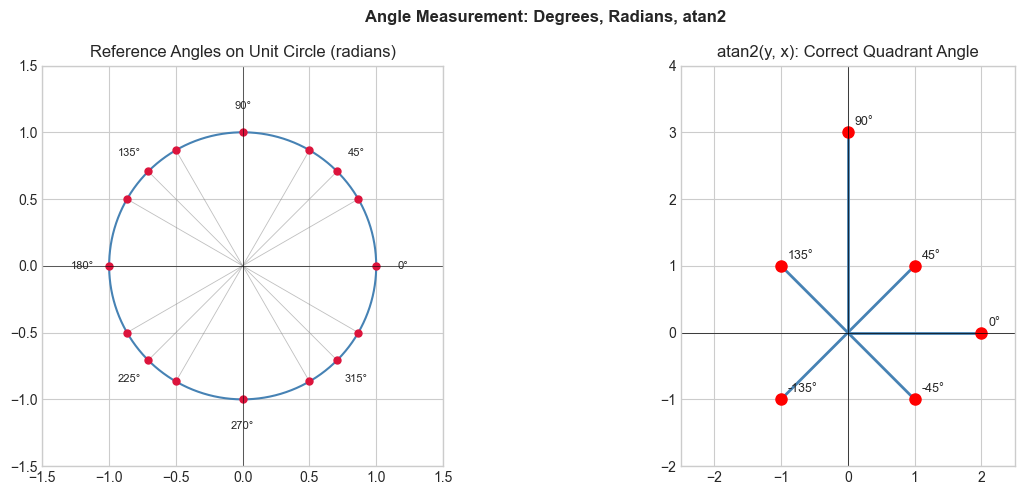

In [4]:
# --- Angle measurement and atan2 ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reference angles on unit circle
theta = np.linspace(0, 2*np.pi, 300)
axes[0].plot(np.cos(theta), np.sin(theta), 'steelblue', linewidth=1.5)
angles_deg = [0, 30, 45, 60, 90, 120, 135, 150, 180, 210, 225, 240, 270, 300, 315, 330]
for deg in angles_deg:
    rad = np.radians(deg)
    axes[0].plot([0, np.cos(rad)], [0, np.sin(rad)], color='gray', linewidth=0.6, alpha=0.5)
    axes[0].plot(np.cos(rad), np.sin(rad), 'o', color='crimson', markersize=5)
    if deg % 45 == 0:
        axes[0].annotate(f'{deg}°', (np.cos(rad)*1.2, np.sin(rad)*1.2), ha='center', va='center', fontsize=8)
axes[0].set_aspect('equal'); axes[0].set_xlim(-1.5,1.5); axes[0].set_ylim(-1.5,1.5)
axes[0].set_title('Reference Angles on Unit Circle (radians)'); axes[0].axhline(0, color='k', linewidth=0.4); axes[0].axvline(0, color='k', linewidth=0.4)

# atan2: correct quadrant angle
pts = [(1,1),(-1,1),(-1,-1),(1,-1),(2,0),(0,3)]
for (x,y) in [(1,1),(-1,1),(-1,-1),(1,-1),(2,0),(0,3)]:
    angle = np.degrees(np.arctan2(y,x))
    axes[1].plot([0,x],[0,y],'steelblue',linewidth=2)
    axes[1].plot(x,y,'ro',markersize=8)
    axes[1].annotate(f'{angle:.0f}°',(x,y),xytext=(5,5),textcoords='offset points',fontsize=9)
axes[1].axhline(0, color='k', linewidth=0.5); axes[1].axvline(0, color='k', linewidth=0.5)
axes[1].set_aspect('equal'); axes[1].set_xlim(-2.5,2.5); axes[1].set_ylim(-2,4)
axes[1].set_title('atan2(y, x): Correct Quadrant Angle')

plt.suptitle('Angle Measurement: Degrees, Radians, atan2', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## The atan2 Function

**atan** (arctan) only returns angles in (-π/2, π/2) — it can't distinguish all quadrants.

**atan2(y, x)** uses the signs of both x and y to return the angle in (-π, π].
It handles:
- x=0 (vertical): returns ±π/2
- All four quadrants correctly
- x<0 correctly (atan alone would be wrong)

Always use `np.arctan2(y, x)` not `np.arctan(y/x)` for 2D angle computation.

## Exercises

**Easy 1.** Convert 270° to radians. Convert 5π/6 to degrees.
**Easy 2.** What angle (in degrees) does the vector (-1, -1) make with the positive x-axis? Verify with atan2.
**Medium 1.** Implement `angle_between(v1, v2)` using the dot product formula: cos(θ) = v1·v2 / (|v1||v2|). Test for perpendicular and parallel vectors.
**Hard.** Prove that d(sin(x))/dx = cos(x) using the limit definition. Confirm numerically with finite differences.

## Summary

- Degrees: intuitive; radians: mathematical. arc = r·θ only in radians.
- atan2(y,x) gives full-quadrant angle in [-π,π]; always prefer over atan
- sin, cos derivatives are clean in radians — why all math software uses radians internally

**Forward:** ch101 (Trigonometry Intuition) builds the full sin/cos machinery; ch131 (Dot Product) uses angles between vectors.